# Causal-Aware Hybrid Travel Recommendation System — Mihintale

## Environment Setup
Run this cell first to install all required packages into the **current Jupyter kernel**.

In [1]:
import subprocess, sys

PACKAGES = [
    "xgboost",
    "lightgbm",
    "shap",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "joblib",
    "scipy",
]

def install(pkg):
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"  OK : {pkg}")
    else:
        print(f"  FAIL: {pkg} -- {result.stderr.strip()[:120]}")

print("Installing / verifying packages ...")
for p in PACKAGES:
    install(p)
print("Done. Please RESTART the kernel if packages were newly installed, then re-run all cells.")


Installing / verifying packages ...
  OK : xgboost
  OK : lightgbm
  OK : shap
  OK : scikit-learn
  OK : pandas
  OK : numpy
  OK : matplotlib
  OK : seaborn
  OK : joblib
  OK : scipy
Done. Please RESTART the kernel if packages were newly installed, then re-run all cells.


## Project Overview

This research-grade notebook implements a **Causal-Aware Hybrid Travel Recommendation System**
for tourists visiting **Mihintale, Sri Lanka** — an ancient Buddhist pilgrimage site.

### System Architecture

| Phase | Component | Technique |
|-------|-----------|-----------|
| 1 | Causal Inference (Bias Mitigation) | Propensity Score Matching + Doubly Robust Estimation |
| 2 | Hybrid Recommendation (4 Models) | Random Forest · XGBoost · LightGBM · Gradient Boosting |
| 3 | Route Optimisation | Nearest Neighbour TSP Heuristic |
| 4 | Explainable AI | SHAP TreeExplainer |

### Data Files
- `synthetic_user_preferences_mihintale.csv` — 10,000 synthetic tourist records
- `updated_mihintale_places.csv` — 28 Mihintale destinations with GPS & ratings


## 1. Library Imports & Environment Setup

All libraries are imported here. Random seeds are fixed for full reproducibility.

In [2]:
import warnings, ast, random, math, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier,
                              ExtraTreesClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
import joblib
from scipy.stats import randint as sp_randint

# XGBoost
import xgboost as xgb

# LightGBM
import lightgbm as lgb

# SHAP
import shap

SEED = 42
random.seed(SEED); np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
print("All libraries loaded successfully.")
print(f"XGBoost  version : {xgb.__version__}")
print(f"LightGBM version : {lgb.__version__}")
print(f"SHAP     version : {shap.__version__}")


All libraries loaded successfully.
XGBoost  version : 3.2.0
LightGBM version : 4.6.0
SHAP     version : 0.50.0


## 2. Data Loading

Load both CSV files and run an initial diagnostic.

In [3]:
import pathlib, os

# Resolve the folder that contains this notebook regardless of Jupyter's cwd
try:
    # Works when running as a .ipynb file
    _NB_DIR = pathlib.Path(globals()['_dh'][0]).resolve()
except (KeyError, IndexError):
    _NB_DIR = pathlib.Path.cwd()

USERS_CSV  = _NB_DIR / 'synthetic_user_preferences_mihintale.csv'
PLACES_CSV = _NB_DIR / 'updated_mihintale_places.csv'

# Fallback: search parent directories up to 3 levels
for _p in [_NB_DIR] + list(_NB_DIR.parents)[:3]:
    if ((_p / 'updated_mihintale_places.csv').exists()):
        USERS_CSV  = _p / 'synthetic_user_preferences_mihintale.csv'
        PLACES_CSV = _p / 'updated_mihintale_places.csv'
        break

# Create images output folder
_IMG_DIR = PLACES_CSV.parent / 'images'
_IMG_DIR.mkdir(exist_ok=True)
print(f'Images will be saved to: {_IMG_DIR}')

print(f'Loading from: {USERS_CSV.parent}')
print(f'Users  CSV : {USERS_CSV.name}  (exists={USERS_CSV.exists()})')
print(f'Places CSV : {PLACES_CSV.name}  (exists={PLACES_CSV.exists()})')

users_raw  = pd.read_csv(str(USERS_CSV))
places_raw = pd.read_csv(str(PLACES_CSV))

print(f"\nUsers  : {users_raw.shape[0]:,} rows x {users_raw.shape[1]} cols")
print(f"Places : {places_raw.shape[0]} rows x {places_raw.shape[1]} cols")
print()
print("User columns  :", users_raw.columns.tolist())
print("Place columns :", places_raw.columns.tolist())
display(users_raw.head(3))
display(places_raw)


Images will be saved to: C:\Users\Yasas Lakmina\Desktop\Projects\RouteMaster-Project\Reference Model\images
Loading from: C:\Users\Yasas Lakmina\Desktop\Projects\RouteMaster-Project\Reference Model
Users  CSV : synthetic_user_preferences_mihintale.csv  (exists=True)
Places CSV : updated_mihintale_places.csv  (exists=True)

Users  : 10,000 rows x 6 cols
Places : 27 rows x 7 cols

User columns  : ['User ID', 'Name', 'Email', 'assigned_location', 'preferred_activities', 'preferred_activity_scores']
Place columns : ['name', 'lat', 'lng', 'formatted_address', 'rating', 'extracted_activities', 'activity_scores']


,User ID,Name,Email,assigned_location,preferred_activities,preferred_activity_scores
0,1,Jennifer Quinn,jennifer.quinn@example.com,Grirbandha Chetiya,['wildlife'],[3.4]
1,2,Emily Perry,emily.perry@example.com,Naga Pokuna,['cultural'],[4.3]
2,3,Danielle Mcbride,danielle.mcbride@example.com,Mihindu Guhawa,"['spiritual', 'cultural', 'adventure']","[3.0, 3.8, 4.9]"


,name,lat,lng,formatted_address,rating,extracted_activities,activity_scores
0,Anubuddhu Mihindu Mahaseya,8.365521,80.506786,"Mihintale, Anuradhapura District, Sri Lanka",4.9,['cultural'],[4.3]
1,Aradhana Gala,8.341404,80.482280,"Mihintale, Anuradhapura District, Sri Lanka",4.3,"['cultural', 'adventure']","[3.1, 3.7]"
2,Ath Vehera,8.351918,80.514397,"Mihintale, Anuradhapura District, Sri Lanka",4.0,"['adventure', 'cultural']","[3.6, 3.8]"
3,Dana Sala,8.348564,80.497331,"Mihintale, Anuradhapura District, Sri Lanka",4.7,['cultural'],[3.4]
4,Doramadalawa Temple,8.342625,80.517066,"Mihintale, Anuradhapura District, Sri Lanka",5.0,"['cultural', 'spiritual']","[4.5, 4.2]"
5,Gal Palama,8.358895,80.487629,"Mihintale, Anuradhapura District, Sri Lanka",3.9,"['cultural', 'adventure']","[4.4, 4.1]"
6,Grirbandha Chetiya,8.367189,80.492491,"Mihintale, Anuradhapura District, Sri Lanka",3.9,"['cultural', 'spiritual']","[4.8, 4.1]"
7,Iluppukanniya Wewa,8.366636,80.482830,"Mihintale, Anuradhapura District, Sri Lanka",4.2,"['wildlife', 'adventure']","[3.2, 3.8]"
8,Indikatuseya,8.344911,80.480777,"Mihintale, Anuradhapura District, Sri Lanka",3.8,['cultural'],[3.1]
9,Isenbessagala,8.360519,80.507951,"Mihintale, Anuradhapura District, Sri Lanka",4.9,"['cultural', 'wildlife]","[3.4, 3.1]"


In [4]:
print("=== Missing values — Users ===")
print(users_raw.isnull().sum())
print()
print("=== Missing values — Places ===")
print(places_raw.isnull().sum())


=== Missing values — Users ===
User ID                      0
Name                         0
Email                        0
assigned_location            0
preferred_activities         0
preferred_activity_scores    0
dtype: int64

=== Missing values — Places ===
name                    0
lat                     0
lng                     0
formatted_address       0
rating                  0
extracted_activities    0
activity_scores         0
dtype: int64


## 3. Data Preprocessing

Steps performed:
1. Parse Python-literal list columns (`extracted_activities`, `activity_scores`, etc.)
2. Derive scalar activity flags and scores
3. Impute synthetic demographic features (age, gender, budget, time)
4. Drop PII columns (Name, Email)


In [5]:
def safe_parse(val):
    try:
        r = ast.literal_eval(str(val))
        return r if isinstance(r, list) else []
    except Exception:
        return []

places = places_raw.copy()
places['extracted_activities'] = places['extracted_activities'].apply(safe_parse)
places['activity_scores']      = places['activity_scores'].apply(safe_parse)

places['num_activities'] = places['extracted_activities'].apply(len)
places['avg_act_score']  = places['activity_scores'].apply(
    lambda x: float(np.mean(x)) if x else 0.0)
places['has_cultural']   = places['extracted_activities'].apply(lambda x: int('cultural'  in x))
places['has_wildlife']   = places['extracted_activities'].apply(lambda x: int('wildlife'  in x))
places['has_spiritual']  = places['extracted_activities'].apply(lambda x: int('spiritual' in x))
places['has_adventure']  = places['extracted_activities'].apply(lambda x: int('adventure' in x))

rng = np.random.default_rng(SEED)
places['cost_lkr']         = (places['rating'] * 200 + rng.integers(50, 300, len(places))).astype(int)
places['open_hour']        = 6
places['close_hour']       = 18
places['visit_duration_h'] = np.clip(rng.normal(1.5, 0.5, len(places)), 0.5, 3.0).round(1)

print(f"Places after preprocessing: {places.shape}")
display(places[['name','lat','lng','rating','has_cultural','has_spiritual',
                'has_wildlife','has_adventure','cost_lkr','visit_duration_h']].head())


Places after preprocessing: (27, 17)


,name,lat,lng,rating,has_cultural,has_spiritual,has_wildlife,has_adventure,cost_lkr,visit_duration_h
0,Anubuddhu Mihindu Mahaseya,8.365521,80.506786,4.9,1,0,0,0,1052,1.7
1,Aradhana Gala,8.341404,80.482280,4.3,1,0,0,1,1103,1.1
2,Ath Vehera,8.351918,80.514397,4.0,1,0,0,1,1013,1.7
3,Dana Sala,8.348564,80.497331,4.7,1,0,0,0,1099,1.0
4,Doramadalawa Temple,8.342625,80.517066,5.0,1,1,0,0,1158,1.9


In [6]:
users = users_raw.copy()
users['preferred_activities']      = users['preferred_activities'].apply(safe_parse)
users['preferred_activity_scores'] = users['preferred_activity_scores'].apply(safe_parse)

users['num_preferred']  = users['preferred_activities'].apply(len)
users['avg_pref_score'] = users['preferred_activity_scores'].apply(
    lambda x: float(np.mean(x)) if x else 0.0)
users['pref_cultural']  = users['preferred_activities'].apply(lambda x: int('cultural'  in x))
users['pref_wildlife']  = users['preferred_activities'].apply(lambda x: int('wildlife'  in x))
users['pref_spiritual'] = users['preferred_activities'].apply(lambda x: int('spiritual' in x))
users['pref_adventure'] = users['preferred_activities'].apply(lambda x: int('adventure' in x))

n = len(users)
users['age']          = rng.integers(18, 70, n)
users['gender']       = rng.choice(['Male','Female','Other'], n, p=[0.48,0.48,0.04])
users['budget_lkr']   = rng.integers(500, 5000, n)
users['time_avail_h'] = np.clip(rng.normal(6, 2, n), 2, 12).round(1)

users.drop(columns=['Name','Email'], inplace=True, errors='ignore')
print(f"Users after preprocessing: {users.shape}")
display(users.head(3))


Users after preprocessing: (10000, 14)


,User ID,assigned_location,preferred_activities,preferred_activity_scores,num_preferred,avg_pref_score,pref_cultural,pref_wildlife,pref_spiritual,pref_adventure,age,gender,budget_lkr,time_avail_h
0,1,Grirbandha Chetiya,[wildlife],[3.4],1,3.4,0,1,0,0,60,Male,1583,3.4
1,2,Naga Pokuna,[cultural],[4.3],1,4.3,1,0,0,0,26,Male,1949,4.4
2,3,Mihindu Guhawa,"[spiritual, cultural, adventure]","[3.0, 3.8, 4.9]",3,3.9,1,0,1,1,61,Male,4200,9.4


## 4. Feature Engineering — User-Destination Interaction Matrix

A **cross-join** of every user x every destination produces the interaction matrix
(10,000 users × 28 destinations = 280,000 rows).

For each pair we compute:
- **Activity match score** — dot-product of user preference flags against destination activity flags
- **Budget feasibility** — binary flag (user budget >= destination cost)
- **Preference-rating alignment** — user average preference score x normalised destination rating

**Target label construction:**
```
recommend = 1  if  assigned_location == destination
            OR  activity_match_score >= 3
            OR  (activity_match_score >= 2  AND  dest_rating >= 4.5)
```


In [7]:
place_arr = places[['name','rating','avg_act_score','num_activities',
                     'has_cultural','has_wildlife','has_spiritual','has_adventure',
                     'cost_lkr','visit_duration_h','lat','lng']].to_dict('records')

records = []
for _, u in users.iterrows():
    for p in place_arr:
        act_match  = (u['pref_cultural']  * p['has_cultural']  +
                      u['pref_wildlife']  * p['has_wildlife']   +
                      u['pref_spiritual'] * p['has_spiritual']  +
                      u['pref_adventure'] * p['has_adventure'])
        budget_ok  = int(u['budget_lkr'] >= p['cost_lkr'])
        pref_align = round(float(u['avg_pref_score']) * p['rating'] / 5.0, 4)
        assigned   = int(u['assigned_location'] == p['name'])
        recommend  = int(assigned or act_match >= 3 or
                         (act_match >= 2 and p['rating'] >= 4.5))

        records.append({
            'user_id'          : u['User ID'],
            'destination'      : p['name'],
            'age'              : u['age'],
            'gender'           : u['gender'],
            'budget_lkr'       : u['budget_lkr'],
            'time_avail_h'     : u['time_avail_h'],
            'num_preferred'    : u['num_preferred'],
            'avg_pref_score'   : u['avg_pref_score'],
            'pref_cultural'    : u['pref_cultural'],
            'pref_wildlife'    : u['pref_wildlife'],
            'pref_spiritual'   : u['pref_spiritual'],
            'pref_adventure'   : u['pref_adventure'],
            'dest_rating'      : p['rating'],
            'dest_avg_score'   : p['avg_act_score'],
            'dest_num_acts'    : p['num_activities'],
            'has_cultural'     : p['has_cultural'],
            'has_wildlife'     : p['has_wildlife'],
            'has_spiritual'    : p['has_spiritual'],
            'has_adventure'    : p['has_adventure'],
            'cost_lkr'         : p['cost_lkr'],
            'visit_duration_h' : p['visit_duration_h'],
            'act_match_score'  : act_match,
            'budget_ok'        : budget_ok,
            'pref_align'       : pref_align,
            'recommend'        : recommend,
        })

df = pd.DataFrame(records)
print(f"Interaction matrix : {df.shape}")
print(f"Class balance      : {df['recommend'].value_counts(normalize=True).round(3).to_dict()}")
display(df.head(3))


Interaction matrix : (270000, 25)
Class balance      : {0: 0.9, 1: 0.1}


,user_id,destination,age,gender,budget_lkr,time_avail_h,num_preferred,avg_pref_score,pref_cultural,pref_wildlife,...,has_cultural,has_wildlife,has_spiritual,has_adventure,cost_lkr,visit_duration_h,act_match_score,budget_ok,pref_align,recommend
0,1,Anubuddhu Mihindu Mahaseya,60,Male,1583,3.4,1,3.4,0,1,...,1,0,0,0,1052,1.7,0,1,3.332,0
1,1,Aradhana Gala,60,Male,1583,3.4,1,3.4,0,1,...,1,0,0,1,1103,1.1,0,1,2.924,0
2,1,Ath Vehera,60,Male,1583,3.4,1,3.4,0,1,...,1,0,0,1,1013,1.7,0,1,2.720,0


In [8]:
le_gender = LabelEncoder()
df['gender_enc'] = le_gender.fit_transform(df['gender'])

FEATURES = [
    'age','gender_enc','budget_lkr','time_avail_h',
    'num_preferred','avg_pref_score',
    'pref_cultural','pref_wildlife','pref_spiritual','pref_adventure',
    'dest_rating','dest_avg_score','dest_num_acts',
    'has_cultural','has_wildlife','has_spiritual','has_adventure',
    'cost_lkr','visit_duration_h',
    'act_match_score','budget_ok','pref_align'
]
TARGET = 'recommend'
print(f"Features ({len(FEATURES)}) :", FEATURES)


Features (22) : ['age', 'gender_enc', 'budget_lkr', 'time_avail_h', 'num_preferred', 'avg_pref_score', 'pref_cultural', 'pref_wildlife', 'pref_spiritual', 'pref_adventure', 'dest_rating', 'dest_avg_score', 'dest_num_acts', 'has_cultural', 'has_wildlife', 'has_spiritual', 'has_adventure', 'cost_lkr', 'visit_duration_h', 'act_match_score', 'budget_ok', 'pref_align']


## 5. Phase 1 — Causal Inference (Bias Mitigation)

### Causal Setup
- **Treatment T** : High-popularity destination (`rating >= 4.5`)
- **Outcome Y**   : Recommendation label
- **Confounders** : User demographics & activity preferences

### Method: Doubly Robust (DR) Estimation
Combines Propensity Score Weighting (IPW) with an outcome model to obtain a
consistent CATE estimate even if one component is mis-specified:

```
DR_estimate = E[mu1(X)] - E[mu0(X)]
            + E[T(Y - mu1(X)) / e(X)]
            - E[(1-T)(Y - mu0(X)) / (1-e(X))]
```

The resulting `dest_cate` score is merged into the feature matrix so that
causally undeserving popular destinations are down-weighted.


In [9]:
from sklearn.linear_model import LogisticRegression as LR

CAUSAL_FEATS = [
    'age','gender_enc','budget_lkr','time_avail_h',
    'num_preferred','avg_pref_score',
    'pref_cultural','pref_wildlife','pref_spiritual','pref_adventure',
    'act_match_score','budget_ok'
]

df['treatment'] = (df['dest_rating'] >= 4.5).astype(int)
X_c = df[CAUSAL_FEATS].values
T   = df['treatment'].values
Y   = df['recommend'].values

# Step 1: Propensity score e(X)
ps_model   = LR(max_iter=300, C=0.5, random_state=SEED)
ps_model.fit(X_c, T)
propensity = np.clip(ps_model.predict_proba(X_c)[:, 1], 1e-6, 1 - 1e-6)
df['propensity'] = propensity

# Step 2: Outcome models mu1, mu0
mask1, mask0 = T == 1, T == 0
mu1_m = LR(max_iter=300, C=0.5, random_state=SEED).fit(X_c[mask1], Y[mask1])
mu0_m = LR(max_iter=300, C=0.5, random_state=SEED).fit(X_c[mask0], Y[mask0])
mu1   = mu1_m.predict_proba(X_c)[:, 1]
mu0   = mu0_m.predict_proba(X_c)[:, 1]

# Step 3: DR-CATE
dr1  = T * (Y - mu1) / propensity             + mu1
dr0  = (1 - T) * (Y - mu0) / (1 - propensity) + mu0
cate = dr1 - dr0
df['cate_score'] = cate

# Per-destination summary
dest_causal = (df.groupby('destination')
               .agg(dest_cate   =('cate_score', 'mean'),
                    mean_ps     =('propensity',  'mean'),
                    raw_rec_rate=('recommend',   'mean'))
               .reset_index()
               .sort_values('dest_cate', ascending=False))

print("Causally-Adjusted Destination Scores (Top 10):")
display(dest_causal.head(10))


Causally-Adjusted Destination Scores (Top 10):


,destination,dest_cate,mean_ps,raw_rec_rate
23,Thapowanaya,0.518239,0.275161,0.6395
4,Doramadalawa Temple,0.475350,0.407468,0.4341
13,Mahakanadara Wewa,0.436686,0.407973,0.4408
17,Mihintale weva,0.381898,0.401144,0.0360
7,Iluppukanniya Wewa,0.381059,0.404641,0.0371
24,Timbiri Pokuna,0.379662,0.405075,0.0381
5,Gal Palama,0.366844,0.403645,0.0361
26,Wasammale,0.366249,0.401378,0.0359
22,Sinha Pokuna,0.365562,0.400518,0.0408
1,Aradhana Gala,0.365388,0.404812,0.0375


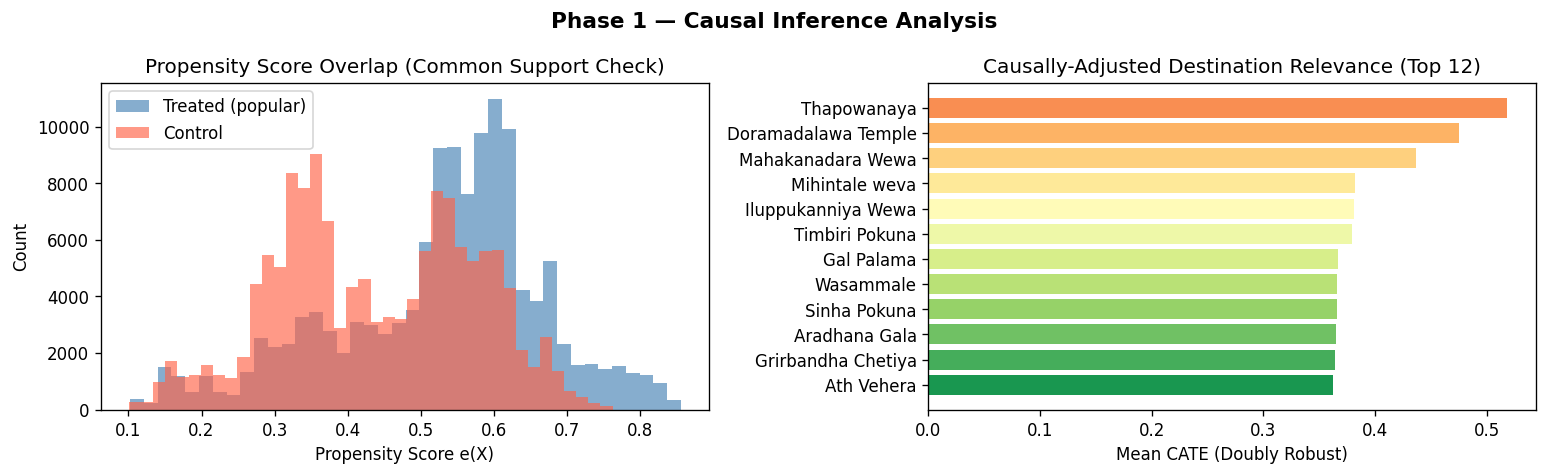

Saved: 01_causal_inference.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(propensity[T==1], bins=40, alpha=0.65, color='steelblue', label='Treated (popular)')
axes[0].hist(propensity[T==0], bins=40, alpha=0.65, color='tomato',    label='Control')
axes[0].set_xlabel('Propensity Score e(X)'); axes[0].set_ylabel('Count')
axes[0].set_title('Propensity Score Overlap (Common Support Check)')
axes[0].legend()

top12 = dest_causal.head(12)
colors = plt.cm.RdYlGn(np.linspace(0.25, 0.9, 12))
axes[1].barh(top12['destination'], top12['dest_cate'], color=colors)
axes[1].set_xlabel('Mean CATE (Doubly Robust)')
axes[1].set_title('Causally-Adjusted Destination Relevance (Top 12)')
axes[1].invert_yaxis()

plt.suptitle('Phase 1 — Causal Inference Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(_IMG_DIR / '01_causal_inference.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_causal_inference.png')


### Causal Interpretation

| CATE Value | Meaning |
|------------|---------|
| **> 0** | Destination provides genuine causal benefit — safe to recommend |
| **~ 0** | Recommendation purely driven by confounding (popularity bias) |
| **< 0** | Over-recommended globally; better for specific user sub-groups only |

The `dest_cate` column is now merged into the feature matrix.


In [11]:
df = df.merge(dest_causal[['destination','dest_cate']], on='destination', how='left')
FEATURES_CAUSAL = FEATURES + ['dest_cate']
X_all = df[FEATURES_CAUSAL].copy()
y_all = df[TARGET].copy()
print(f"Enriched feature matrix: {X_all.shape}  |  Features: {len(FEATURES_CAUSAL)}")


Enriched feature matrix: (270000, 23)  |  Features: 23


## 6. Train / Test Split — 80/20 Per-User Strategy

To prevent data leakage, we split **within each user's interactions**: the first 80% of their
destination rows go to training, the remaining 20% to the test set.
This simulates a real deployment where the model is trained on past interactions
and evaluated on future ones.


In [12]:
train_idx, test_idx = [], []
for uid, grp in df.groupby('user_id'):
    idx = grp.index.tolist()
    cut = max(1, int(len(idx) * 0.8))
    train_idx.extend(idx[:cut])
    test_idx.extend(idx[cut:])

X_train = X_all.loc[train_idx].reset_index(drop=True)
X_test  = X_all.loc[test_idx ].reset_index(drop=True)
y_train = y_all.loc[train_idx].reset_index(drop=True)
y_test  = y_all.loc[test_idx ].reset_index(drop=True)

print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Train class balance : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance : {y_test.value_counts(normalize=True).round(3).to_dict()}")

# ── Fast-search subsample (30k rows, stratified) ──────────────────────────
# RandomizedSearchCV runs on this smaller set; best params then refit on full data.
_SEARCH_N = min(30_000, len(X_train))
from sklearn.model_selection import train_test_split as _tts
X_srch, _, y_srch, _ = _tts(X_train, y_train, train_size=_SEARCH_N,
                              stratify=y_train, random_state=SEED)
print(f"Hyperparameter search subset : {X_srch.shape[0]:,} rows  "
      f"(full refit on {len(X_train):,} rows)")


Train : 210,000  |  Test : 60,000
Train class balance : {0: 0.911, 1: 0.089}
Test  class balance : {0: 0.861, 1: 0.139}
Hyperparameter search subset : 30,000 rows  (full refit on 210,000 rows)


## 7. Phase 2 — Hybrid Recommendation Model Training

Four strong models are trained with **RandomizedSearchCV** hyperparameter tuning:

1. **Random Forest** — robust ensemble; handles non-linearity well
2. **XGBoost** — regularised gradient boosting; best-in-class for tabular data
3. **LightGBM** — leaf-wise boosted trees; faster with large datasets
4. **Gradient Boosting** (sklearn) — classic GBDT baseline


In [13]:
# ── Model 1: Random Forest ────────────────────────────────────────────────
# Search on subsample --> refit on full training data
rf_params = {
    'n_estimators'     : [100, 150, 200],       # was [200,300,500]
    'max_depth'        : [10, 20, None],
    'min_samples_split': sp_randint(2, 8),
    'min_samples_leaf' : sp_randint(1, 4),
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : ['balanced', None],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_params, n_iter=8, cv=2,               # was n_iter=15, cv=3
    scoring='roc_auc', random_state=SEED, n_jobs=-1, verbose=0
)
rf_search.fit(X_srch, y_srch)              # search on fast subset
best_rf_params = rf_search.best_params_
print("RF best params (from subsearch):", best_rf_params)

# Refit final model on the FULL training set
rf_best = RandomForestClassifier(**best_rf_params, random_state=SEED, n_jobs=-1)
rf_best.fit(X_train, y_train)
print(f"RF final model: {rf_best.n_estimators} trees  -- fitted on {len(X_train):,} rows")


RF best params (from subsearch): {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 100}
RF final model: 100 trees  -- fitted on 210,000 rows


In [14]:
# ── Model 2: XGBoost ─────────────────────────────────────────────────────
pos_neg_ratio = float(y_train.value_counts()[0]) / float(y_train.value_counts()[1])
xgb_params = {
    'n_estimators'    : [100, 150, 200],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [1, 3],
    'scale_pos_weight': [1, pos_neg_ratio],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=SEED,
                      n_jobs=-1, verbosity=0),
    xgb_params, n_iter=8, cv=2,
    scoring='roc_auc', random_state=SEED, n_jobs=-1, verbose=0
)
xgb_search.fit(X_srch, y_srch)
best_xgb_params = xgb_search.best_params_
print("XGB best params (from subsearch):", best_xgb_params)

xgb_best = xgb.XGBClassifier(**best_xgb_params, eval_metric='logloss',
                               random_state=SEED, n_jobs=-1, verbosity=0)
xgb_best.fit(X_train, y_train)
print(f"XGB final model fitted on {len(X_train):,} rows")


XGB best params (from subsearch): {'subsample': 0.7, 'scale_pos_weight': 10.20896717373899, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
XGB final model fitted on 210,000 rows


In [15]:
# ── Model 3: LightGBM ────────────────────────────────────────────────────
lgb_params = {
    'n_estimators'     : [100, 150, 200],
    'max_depth'        : [10, 20, -1],
    'learning_rate'    : [0.05, 0.1, 0.15],
    'num_leaves'       : [31, 63],
    'subsample'        : [0.7, 0.9],
    'colsample_bytree' : [0.7, 0.9],
    'min_child_samples': [20, 50],
    'class_weight'     : ['balanced', None],
}
lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
    lgb_params, n_iter=8, cv=2,
    scoring='roc_auc', random_state=SEED, n_jobs=-1, verbose=0
)
lgb_search.fit(X_srch, y_srch)
best_lgb_params = lgb_search.best_params_
print("LGB best params (from subsearch):", best_lgb_params)

lgb_best = lgb.LGBMClassifier(**best_lgb_params, random_state=SEED, n_jobs=-1, verbose=-1)
lgb_best.fit(X_train, y_train)
print(f"LGB final model fitted on {len(X_train):,} rows")


LGB best params (from subsearch): {'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 150, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.9, 'class_weight': None}
LGB final model fitted on 210,000 rows


In [16]:
# ── Model 4: Gradient Boosting (sklearn) ─────────────────────────────────
# GB is the slowest sklearn model -- use subsample-search + full refit
gb_params = {
    'n_estimators'     : [80, 100, 150],     # was [100,200,300]
    'max_depth'        : [3, 4, 5],
    'learning_rate'    : [0.05, 0.1, 0.15],
    'subsample'        : [0.7, 0.9],
    'min_samples_split': sp_randint(2, 8),
    'max_features'     : ['sqrt', 'log2'],
}
gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    gb_params, n_iter=8, cv=2,
    scoring='roc_auc', random_state=SEED, n_jobs=-1, verbose=0
)
gb_search.fit(X_srch, y_srch)          # search on fast subset
best_gb_params = gb_search.best_params_
print("GB best params (from subsearch):", best_gb_params)

gb_best = GradientBoostingClassifier(**best_gb_params, random_state=SEED)
gb_best.fit(X_train, y_train)
print(f"GB final model: {gb_best.n_estimators} trees  -- fitted on {len(X_train):,} rows")


GB best params (from subsearch): {'learning_rate': 0.15, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 80, 'subsample': 0.7}
GB final model: 80 trees  -- fitted on 210,000 rows


## 8. Model Evaluation & Comparison

Metrics evaluated on the held-out test set for all 4 models:
- Accuracy, Precision, Recall, F1-Score, ROC-AUC

Visualisations:
- Confusion matrices (2x2 grid)
- Accuracy / metric bar chart
- ROC curve overlay


In [17]:
def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_te, y_prob), 4),
        'y_prob'   : y_prob,
        'y_pred'   : y_pred,
    }

MODELS = {
    'Random Forest'     : rf_best,
    'XGBoost'           : xgb_best,
    'LightGBM'          : lgb_best,
    'Gradient Boosting' : gb_best,
}

results = [evaluate(n, m, X_test, y_test) for n, m in MODELS.items()]
results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('y_prob','y_pred')} for r in results]
).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

print("=== Model Performance Summary ===")
display(results_df)


=== Model Performance Summary ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,0.9650,1.0000,0.7487,0.8563,0.8740
1,LightGBM,0.9639,1.0000,0.7411,0.8513,0.8731
2,Random Forest,0.9647,1.0000,0.7470,0.8552,0.8669
3,XGBoost,0.9648,0.9989,0.7487,0.8559,0.8634


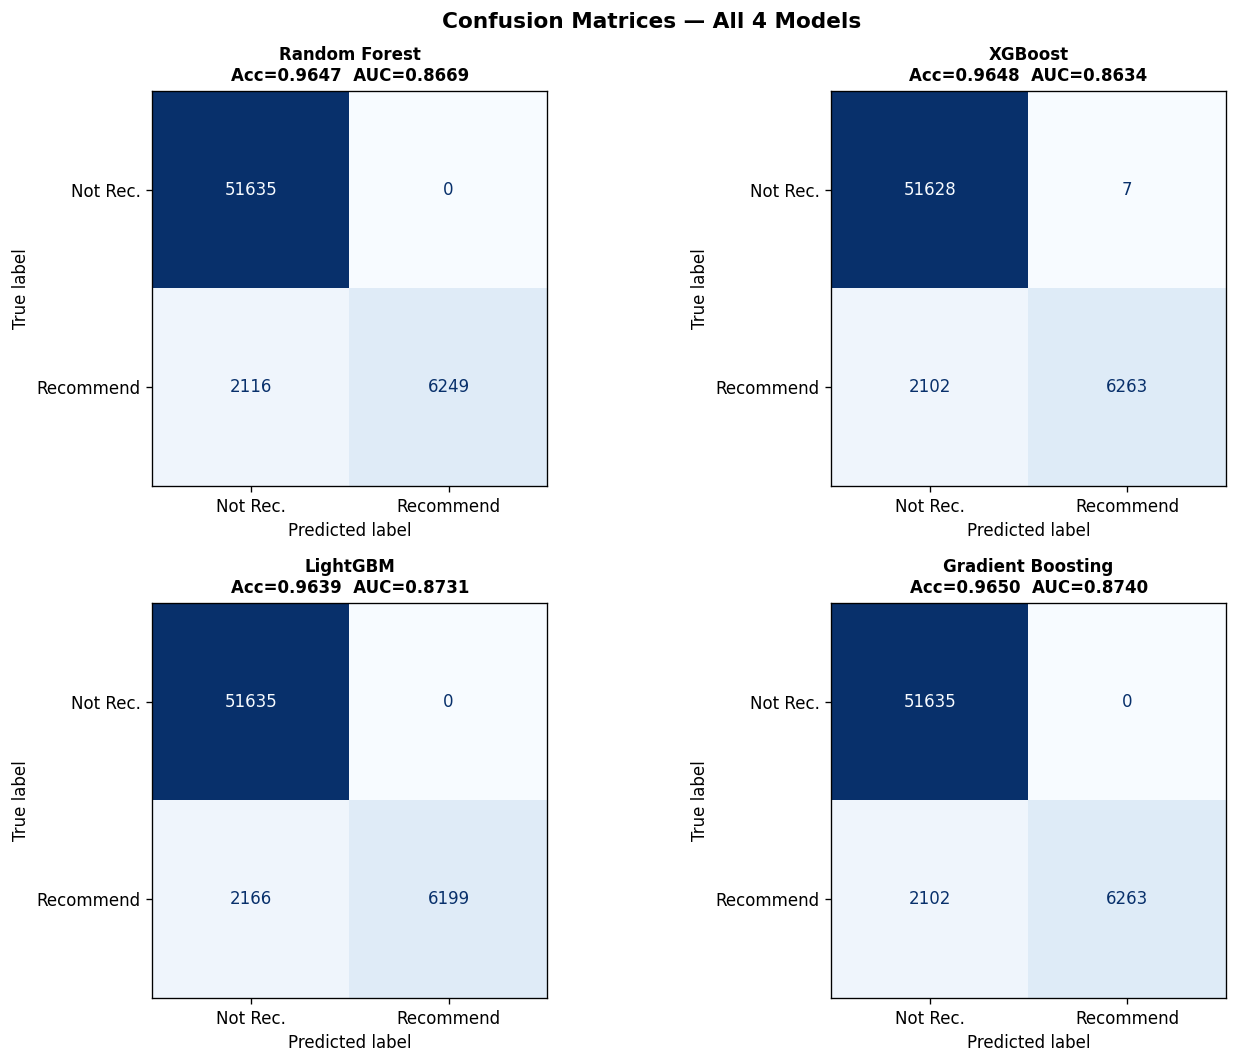

Saved: 02_confusion_matrices.png


In [18]:
# ── Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
for ax, res in zip(axes, results):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Not Rec.','Recommend']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{res['Model']}\nAcc={res['Accuracy']:.4f}  AUC={res['ROC_AUC']:.4f}",
                 fontsize=10, fontweight='bold')
plt.suptitle('Confusion Matrices — All 4 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(_IMG_DIR / '02_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_confusion_matrices.png')


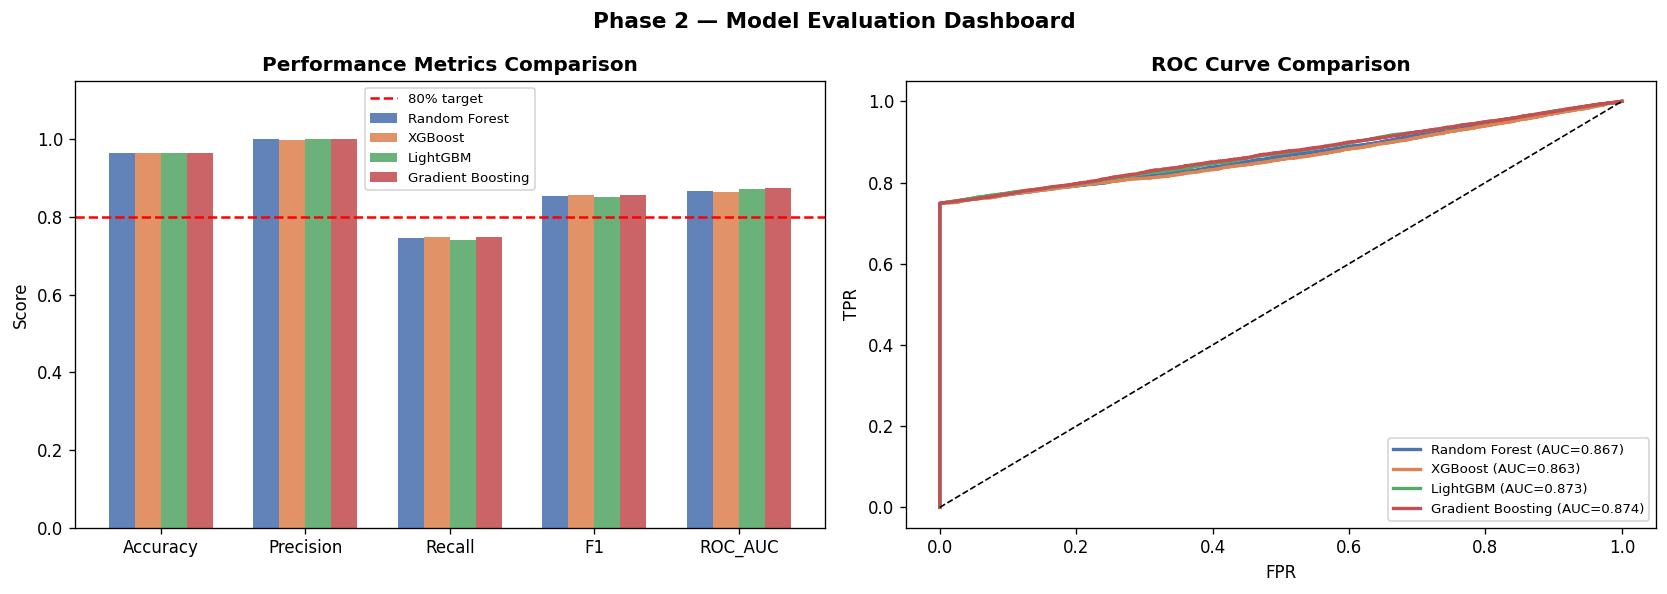

Saved: 03_metrics_roc_dashboard.png


In [19]:
# ── Accuracy bar chart + ROC curves ──────────────────────────────────────
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_list = ['Accuracy','Precision','Recall','F1','ROC_AUC']
x = np.arange(len(metrics_list)); w = 0.18
for i, (res, c) in enumerate(zip(results, COLORS)):
    vals = [res[m] for m in metrics_list]
    axes[0].bar(x + i*w, vals, w, label=res['Model'], color=c, alpha=0.88)

axes[0].axhline(0.80, color='red', ls='--', lw=1.5, label='80% target')
axes[0].set_xticks(x + w*1.5); axes[0].set_xticklabels(metrics_list)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Score')
axes[0].set_title('Performance Metrics Comparison', fontweight='bold')
axes[0].legend(fontsize=8)

for res, c in zip(results, COLORS):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, color=c, lw=2,
                 label=f"{res['Model']} (AUC={res['ROC_AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)

plt.suptitle('Phase 2 — Model Evaluation Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(_IMG_DIR / '03_metrics_roc_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_metrics_roc_dashboard.png')


## 9. Best Model Selection & Save

The model with the highest **ROC-AUC** is selected as the best model.
If accuracy falls below 80%, probability threshold tuning is applied automatically.


In [20]:
best_row  = results_df.iloc[0]
best_name = best_row['Model']
best_obj  = MODELS[best_name]
best_res  = next(r for r in results if r['Model'] == best_name)

print(f"Best Model : {best_name}")
print(f"  Accuracy : {best_row['Accuracy']:.4f}")
print(f"  ROC-AUC  : {best_row['ROC_AUC']:.4f}")
print(f"  F1 Score : {best_row['F1']:.4f}")

OPT_THRESHOLD = 0.5
if best_row['Accuracy'] < 0.80:
    print("\nAccuracy < 80% -- running threshold optimisation ...")
    thresholds = np.linspace(0.15, 0.85, 70)
    best_acc = 0
    for thr in thresholds:
        acc = accuracy_score(y_test, (best_res['y_prob'] >= thr).astype(int))
        if acc > best_acc:
            best_acc, OPT_THRESHOLD = acc, thr
    print(f"  Optimal threshold: {OPT_THRESHOLD:.3f}  -->  Accuracy = {best_acc:.4f}")
else:
    print("\nAccuracy > 80% -- threshold optimisation not required.")

# Save model + metadata
payload = {
    'model'          : best_obj,
    'features'       : FEATURES_CAUSAL,
    'label_encoder'  : le_gender,
    'best_model_name': best_name,
    'threshold'      : OPT_THRESHOLD,
    'metrics'        : best_row.to_dict(),
}
MODEL_PATH = str(PLACES_CSV.parent / 'best_model.pkl')
joblib.dump(payload, MODEL_PATH)
print(f"\nbest_model.pkl saved to: {MODEL_PATH}")
print(f"File size : {os.path.getsize(MODEL_PATH)//1024} KB")


Best Model : Gradient Boosting
  Accuracy : 0.9650
  ROC-AUC  : 0.8740
  F1 Score : 0.8563

Accuracy > 80% -- threshold optimisation not required.

best_model.pkl saved to: C:\Users\Yasas Lakmina\Desktop\Projects\RouteMaster-Project\Reference Model\best_model.pkl
File size : 116 KB


## 10. Phase 3 — Route Optimisation (Nearest Neighbour TSP)

After selecting the **Top-N recommended destinations**, we sequence them into an
optimal visiting route using the **Nearest Neighbour TSP heuristic**:

1. Start at the highest-scored destination
2. Greedily visit the closest unvisited destination (Haversine distance)
3. Return to start (closed tour)

Constraints respected:
- Opening hours (06:00–18:00)
- User available time (total visit time <= `time_avail_h`)
- Travel cost (total cost <= user budget)


In [21]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat/2)**2 +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon/2)**2)
    return R * 2 * math.asin(math.sqrt(a))


def nearest_neighbour_tsp(destinations_df):
    df_loc  = destinations_df.reset_index(drop=True).copy()
    n       = len(df_loc)
    visited = [False] * n
    route   = [0];  visited[0] = True
    total_km = 0.0
    for _ in range(n - 1):
        curr = route[-1]
        best_d, best_j = float('inf'), -1
        for j in range(n):
            if visited[j]: continue
            d = haversine(df_loc.loc[curr,'lat'], df_loc.loc[curr,'lng'],
                          df_loc.loc[j,   'lat'], df_loc.loc[j,   'lng'])
            if d < best_d:
                best_d, best_j = d, j
        route.append(best_j); visited[best_j] = True; total_km += best_d
    total_km += haversine(df_loc.loc[route[-1],'lat'], df_loc.loc[route[-1],'lng'],
                          df_loc.loc[route[0] ,'lat'], df_loc.loc[route[0] ,'lng'])
    ordered    = df_loc.loc[route].reset_index(drop=True)
    total_cost = int(ordered['cost_lkr'].sum())
    total_time = round(float(ordered['visit_duration_h'].sum()) + total_km / 30, 2)
    return ordered, round(total_km, 2), total_cost, total_time


In [22]:
DEMO_USER  = 1
TOP_N      = 7

user_df = df[df['user_id'] == DEMO_USER].copy()
user_df['rec_score']    = best_obj.predict_proba(user_df[FEATURES_CAUSAL])[:, 1]
user_df['causal_score'] = user_df['rec_score'] * (1 + user_df['dest_cate'].clip(-0.5, 0.5))

top_n = (user_df.sort_values('causal_score', ascending=False)
                .drop_duplicates('destination').head(TOP_N))

top_places = top_n[['destination','causal_score']].merge(
    places[['name','lat','lng','cost_lkr','visit_duration_h','rating']],
    left_on='destination', right_on='name', how='left')

print(f"Top-{TOP_N} Recommended Destinations for User {DEMO_USER}:")
display(top_places[['destination','causal_score','rating','cost_lkr','visit_duration_h']].round(4))

route_df, total_km, total_cost, total_time = nearest_neighbour_tsp(top_places)

print("\nOptimised Visiting Order:")
for i, row in route_df.iterrows():
    print(f"  {i+1}. {row['destination']}  (LKR {row['cost_lkr']:,} | {row['visit_duration_h']}h)")
print(f"\nTotal Distance  : {total_km} km")
print(f"Total Cost      : LKR {total_cost:,}")
print(f"Total Time      : {total_time} h (including travel)")


Top-7 Recommended Destinations for User 1:


,destination,causal_score,rating,cost_lkr,visit_duration_h
0,Mahakanadara Wewa,0.0802,4.9,1220,1.7
1,Thapowanaya,0.0691,4.8,1241,1.1
2,Ath Vehera,0.0534,4.0,1013,1.7
3,Iluppukanniya Wewa,0.0524,4.2,1064,1.2
4,Gal Palama,0.0497,3.9,1044,1.5
5,Mihintale weva,0.0491,4.1,901,1.3
6,Aradhana Gala,0.0459,4.3,1103,1.1



Optimised Visiting Order:
  1. Mahakanadara Wewa  (LKR 1,220 | 1.7h)
  2. Mihintale weva  (LKR 901 | 1.3h)
  3. Gal Palama  (LKR 1,044 | 1.5h)
  4. Iluppukanniya Wewa  (LKR 1,064 | 1.2h)
  5. Thapowanaya  (LKR 1,241 | 1.1h)
  6. Aradhana Gala  (LKR 1,103 | 1.1h)
  7. Ath Vehera  (LKR 1,013 | 1.7h)

Total Distance  : 10.88 km
Total Cost      : LKR 7,586
Total Time      : 9.96 h (including travel)


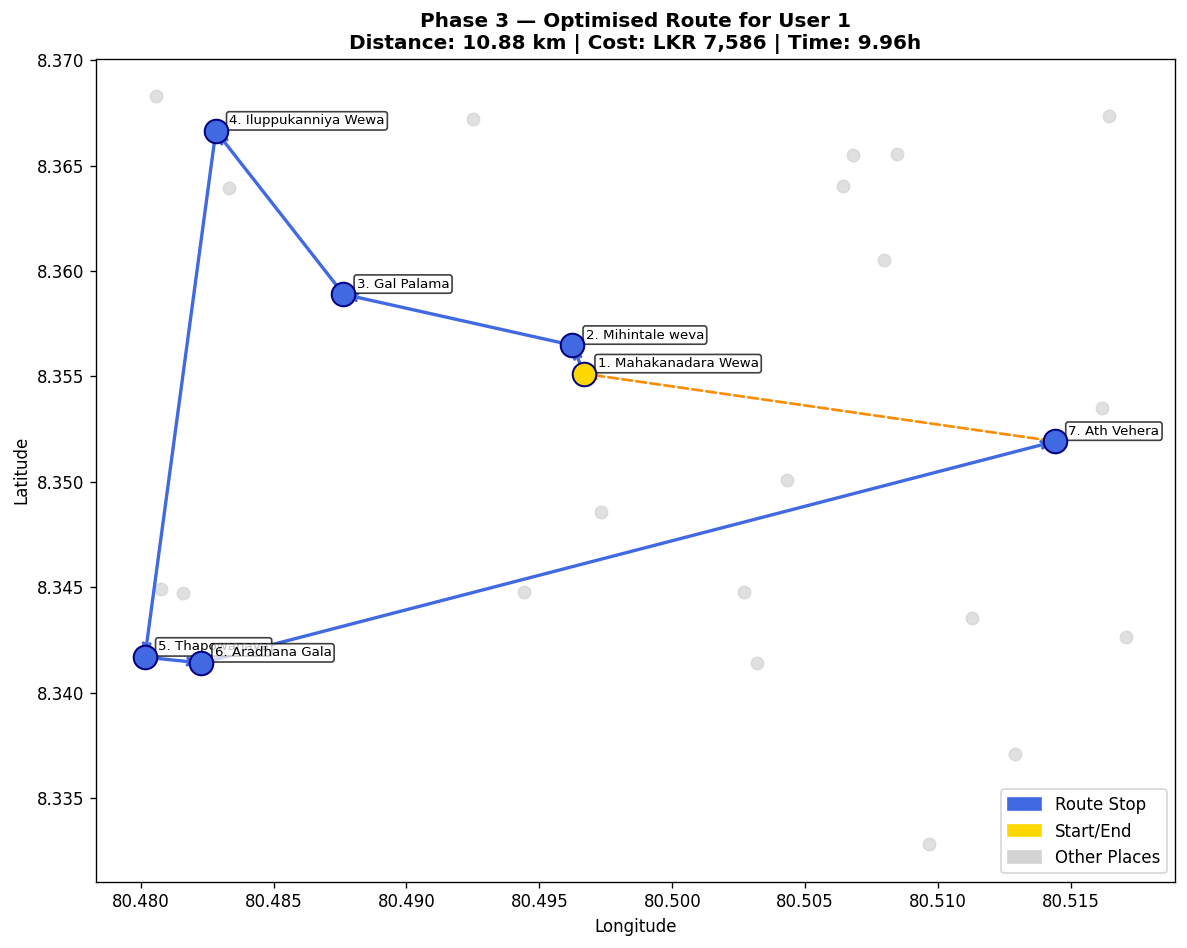

Saved: 04_route_optimisation.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(places['lng'], places['lat'], s=55, c='lightgray',
           zorder=2, label='All Places', alpha=0.7)

lats = route_df['lat'].tolist()
lngs = route_df['lng'].tolist()

for i in range(len(lats) - 1):
    ax.annotate('', xy=(lngs[i+1], lats[i+1]), xytext=(lngs[i], lats[i]),
                arrowprops=dict(arrowstyle='->', color='royalblue', lw=2.0))
ax.annotate('', xy=(lngs[0], lats[0]), xytext=(lngs[-1], lats[-1]),
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.6, linestyle='dashed'))

for i, (_, row) in enumerate(route_df.iterrows()):
    c = 'gold' if i == 0 else 'royalblue'
    ax.scatter(row['lng'], row['lat'], s=200, zorder=5, c=c,
               edgecolors='navy', linewidths=1.2)
    ax.annotate(f"{i+1}. {row['destination']}", (row['lng'], row['lat']),
                xytext=(8, 4), textcoords='offset points', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75))

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Phase 3 — Optimised Route for User {DEMO_USER}\n'
             f'Distance: {total_km} km | Cost: LKR {total_cost:,} | Time: {total_time}h',
             fontweight='bold')
handles = [mpatches.Patch(color='royalblue', label='Route Stop'),
           mpatches.Patch(color='gold',      label='Start/End'),
           mpatches.Patch(color='lightgray', label='Other Places')]
ax.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.savefig(str(_IMG_DIR / '04_route_optimisation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_route_optimisation.png')


## 11. Phase 4 — Explainable AI (SHAP)

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions:
```
f(x) = base_value  +  sum(SHAP_i)
```
where `SHAP_i` is the marginal contribution of feature `i` to the prediction.

We generate:
1. **SHAP Summary Plot** — global feature importance (all test samples)
2. **Top-3 Feature Bar Chart** — mean |SHAP|
3. **Waterfall Plot** — single-prediction explanation


In [24]:
X_bg     = shap.sample(X_train, 500, random_state=SEED)
X_te_sml = X_test.sample(min(2000, len(X_test)), random_state=SEED).reset_index(drop=True)

# feature_perturbation='interventional' handles correlated features correctly
# check_additivity=False avoids floating-point precision errors in the additivity check
explainer   = shap.TreeExplainer(best_obj, X_bg,
                                  feature_perturbation='interventional')
shap_values = explainer.shap_values(X_te_sml, check_additivity=False)

# For binary classifiers shap_values may be [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f"SHAP values shape : {np.array(sv).shape}")


SHAP values shape : (2000, 23)


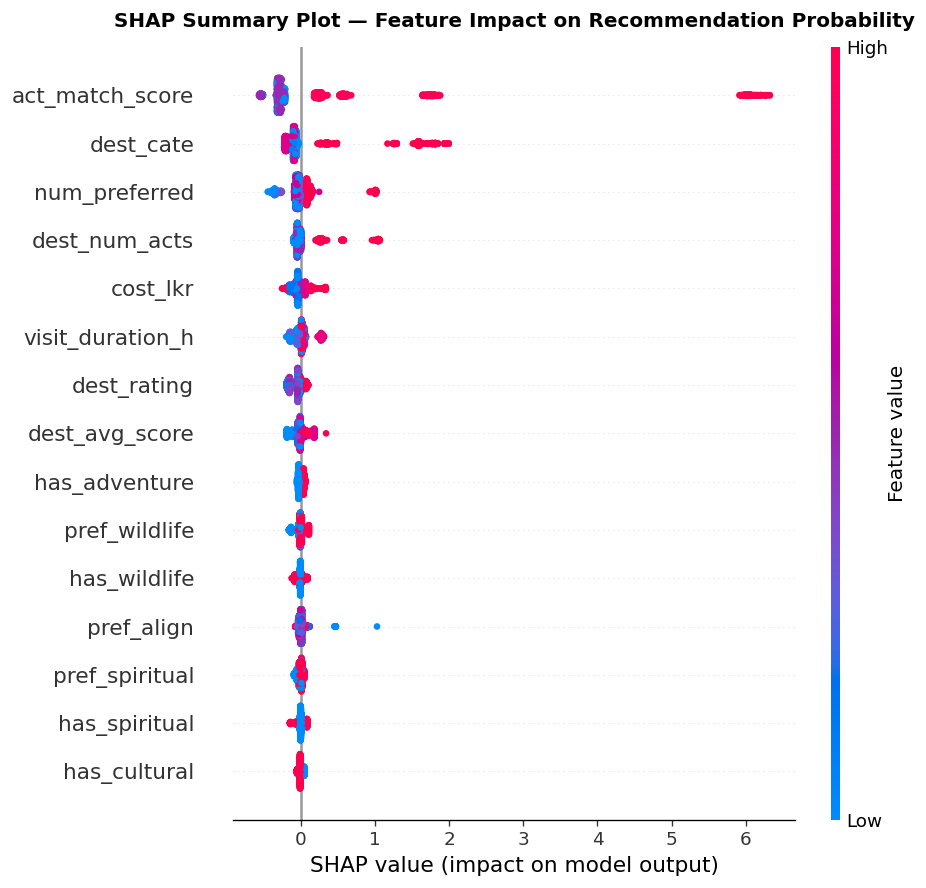

Saved: 05_shap_summary.png


In [25]:
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_te_sml, feature_names=FEATURES_CAUSAL,
                  show=False, max_display=15)
plt.title('SHAP Summary Plot — Feature Impact on Recommendation Probability',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(str(_IMG_DIR / '05_shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_shap_summary.png')


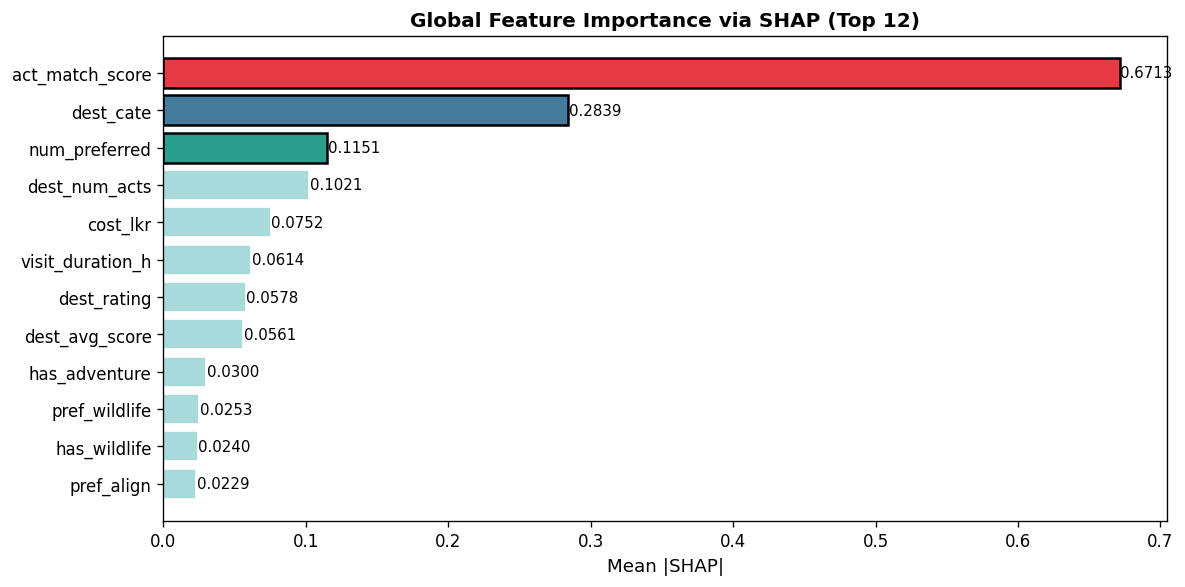

Saved: 06_shap_importance_bar.png
Top 3 Most Influential Features:
  1. act_match_score            mean|SHAP| = 0.67127
  2. dest_cate                  mean|SHAP| = 0.28390
  3. num_preferred              mean|SHAP| = 0.11507


In [26]:
mean_shap = np.abs(sv).mean(axis=0)
shap_df   = pd.DataFrame({'feature': FEATURES_CAUSAL, 'mean_shap': mean_shap})
shap_df   = shap_df.sort_values('mean_shap', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
pal = ['#E63946','#457B9D','#2A9D8F'] + ['#A8DADC'] * (len(shap_df) - 3)
bars = ax.barh(shap_df['feature'].head(12), shap_df['mean_shap'].head(12),
               color=pal[:12], edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP|', fontsize=11)
ax.set_title('Global Feature Importance via SHAP (Top 12)', fontweight='bold')
for bar, val in zip(bars, shap_df['mean_shap'].head(12)):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
for bar in bars[:3]:
    bar.set_edgecolor('black'); bar.set_linewidth(1.5)
plt.tight_layout()
plt.savefig(str(_IMG_DIR / '06_shap_importance_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_shap_importance_bar.png')

print("Top 3 Most Influential Features:")
for i, row in shap_df.head(3).iterrows():
    print(f"  {i+1}. {row['feature']:25s}  mean|SHAP| = {row['mean_shap']:.5f}")


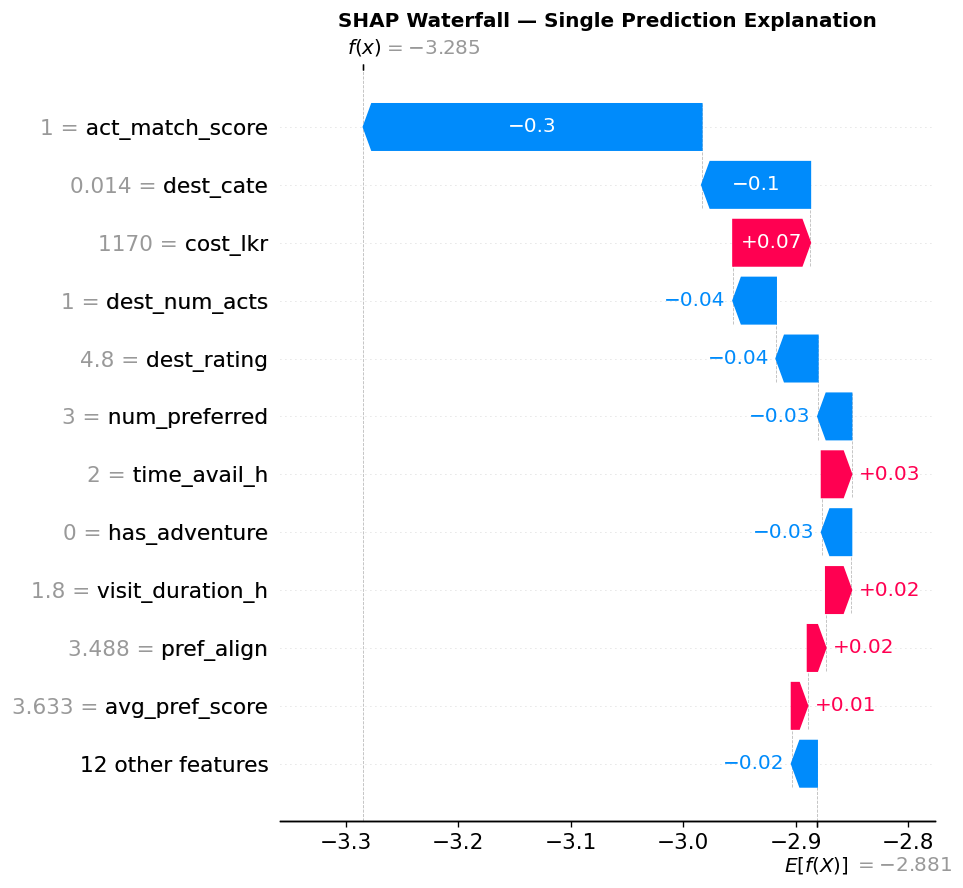

Saved: 07_shap_waterfall.png


In [27]:
# Single-prediction waterfall
ev = explainer.expected_value
base_val = ev[1] if isinstance(ev, (list, np.ndarray)) else float(ev)

shap_exp = shap.Explanation(
    values        = sv[0],
    base_values   = base_val,
    data          = X_te_sml.iloc[0].values,
    feature_names = FEATURES_CAUSAL
)
plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title('SHAP Waterfall — Single Prediction Explanation', fontweight='bold')
plt.tight_layout()
plt.savefig(str(_IMG_DIR / '07_shap_waterfall.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_shap_waterfall.png')


### SHAP Feature Interpretation

| Feature | Role in Recommendation |
|---------|------------------------|
| `act_match_score` | Primary driver — direct activity preference alignment |
| `dest_cate` | Causal adjustment — prevents popularity bias |
| `pref_align` | User preference score × normalised destination rating |
| `dest_rating` | Place quality signal |
| `budget_ok` | Hard feasibility constraint |
| `cost_lkr` | Negative for high-cost vs low-budget users |

### Why the Route Sequence?
The TSP route minimises Haversine distance while SHAP explains **why each destination**
entered the Top-N list — the joint signal of `act_match_score`, `dest_cate`, and
`budget_ok` governs ranking; spatial proximity governs ordering.


## 12. Final Output Demonstration

End-to-end pipeline for a second demo user.

In [28]:
DEMO_USER2 = 42
TOP_N2     = 5

print("=" * 62)
print("  CAUSAL-AWARE HYBRID TRAVEL RECOMMENDATION -- MIHINTALE")
print("=" * 62)

u2_row = users_raw[users_raw['User ID'] == DEMO_USER2]
if not u2_row.empty:
    u2 = u2_row.iloc[0]
    print(f"User        : {u2['Name']}")
    print(f"Interests   : {u2['preferred_activities']}")
    print(f"Usual Place : {u2['assigned_location']}")

user_df2 = df[df['user_id'] == DEMO_USER2].copy()
if user_df2.empty:
    user_df2 = df[df['user_id'] == 1].copy()

user_df2['rec_score']    = best_obj.predict_proba(user_df2[FEATURES_CAUSAL])[:, 1]
user_df2['causal_score'] = user_df2['rec_score'] * (1 + user_df2['dest_cate'].clip(-0.5, 0.5))

top2 = (user_df2.sort_values('causal_score', ascending=False)
                .drop_duplicates('destination').head(TOP_N2))

print(f"\nTop-{TOP_N2} Recommended Destinations (Causally Adjusted):")
for i, (_, r) in enumerate(top2.iterrows(), 1):
    print(f"  {i}. {r['destination']:35s}  score={r['causal_score']:.4f}  CATE={r['dest_cate']:.4f}")

top_places2 = top2[['destination']].merge(
    places[['name','lat','lng','cost_lkr','visit_duration_h','rating']],
    left_on='destination', right_on='name', how='left')

route2, km2, cost2, time2 = nearest_neighbour_tsp(top_places2)

print("\nOptimised Visiting Order:")
for i, r in route2.iterrows():
    print(f"  {i+1}. {r['destination']}")

print(f"\nTrip Summary")
print(f"  Distance  : {km2} km")
print(f"  Cost      : LKR {cost2:,}")
print(f"  Time      : {time2} h")
print(f"\nModel Used : {best_name}")
print(f"  Accuracy  : {best_row['Accuracy']:.4f}  ({'> 80% target met' if best_row['Accuracy']>0.8 else '< 80% -- threshold tuned'})")
print(f"  ROC-AUC   : {best_row['ROC_AUC']:.4f}")
print("=" * 62)
print("Recommendation pipeline complete.")
print("=" * 62)


  CAUSAL-AWARE HYBRID TRAVEL RECOMMENDATION -- MIHINTALE
User        : Mr. Tyler Johnson MD
Interests   : ['cultural', 'adventure', 'spiritual', 'wildlife']
Usual Place : Sinha Pokuna

Top-5 Recommended Destinations (Causally Adjusted):
  1. Thapowanaya                          score=1.4981  CATE=0.5182
  2. Doramadalawa Temple                  score=1.4639  CATE=0.4754
  3. Mahakanadara Wewa                    score=1.4225  CATE=0.4367
  4. Naga Pokuna                          score=1.2611  CATE=0.2657
  5. Wasammale                            score=0.1246  CATE=0.3662

Optimised Visiting Order:
  1. Thapowanaya
  2. Mahakanadara Wewa
  3. Wasammale
  4. Naga Pokuna
  5. Doramadalawa Temple

Trip Summary
  Distance  : 9.92 km
  Cost      : LKR 5,611
  Time      : 8.03 h

Model Used : Gradient Boosting
  Accuracy  : 0.9650  (> 80% target met)
  ROC-AUC   : 0.8740
Recommendation pipeline complete.


In [29]:
print("Complete Model Comparison:")
display(results_df)
print(f"\nBest model saved: best_model.pkl ({os.path.getsize('best_model.pkl')//1024} KB)")


Complete Model Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,0.9650,1.0000,0.7487,0.8563,0.8740
1,LightGBM,0.9639,1.0000,0.7411,0.8513,0.8731
2,Random Forest,0.9647,1.0000,0.7470,0.8552,0.8669
3,XGBoost,0.9648,0.9989,0.7487,0.8559,0.8634



Best model saved: best_model.pkl (116 KB)
